# Experiments wrapping sampling functions

This will allow to implement algorithms that require refitting in ArviZ.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

In [2]:
xdata = np.linspace(0,10,20)
b1, b0, sigma = 1, -2, 3
ydata = np.random.normal(loc=b1*xdata + b0, scale=sigma)

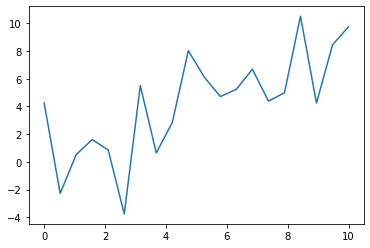

In [3]:
plt.plot(xdata, ydata)

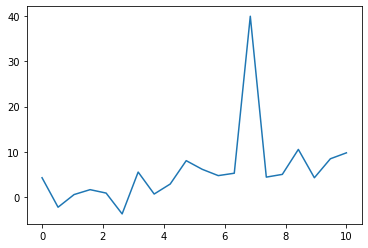

In [4]:
ydata[13] = 40
plt.plot(xdata, ydata)

In [5]:
data_dict = {"N": len(xdata), "x": xdata, "y": ydata}

In [42]:
class SamplingWrapper:
    
    def __init__(self, model, idata):
        self.model = model
        self.idata = idata
        if hasattr(idata, "observed_data"):
            self._observed_data = idata.observed_data
        else:
            raise AttributeError("InferenceData must contain observed data group")
            
    def sel_observations(self, idx):
        raise NotImplementedError("sel_observations method must be implemented for each subclass")
            
    def sample(self, modified_observed_data, **kwargs):
        raise NotImplementedError("sample method must be implemented for each subclass")
        
    def get_inference_data(self, fit_object, **kwargs):
        raise NotImplementedError("get_inference_data method must be implemented for each subclass")        

# PyStan wrapper

In [43]:
class PyStanSamplingWrapper(SamplingWrapper):
    
    def sel_observations(delf, idx):
        obs_data = self._observed_data
        xdata = obs_data.x.values
        mask = np.full_like(xdata, True)
        mask[idx] = False
        try:
            M = len(idx)
        except TypeError:
            M = 1
        observations = {
            "N": obs_data.N.item()-M,
            "x": xdata[mask],
            "y": obs_data.y.values[mask],
        }
        return obvervations
    
    def sample(self, modified_observed_data, **kwargs):
        fit = self.model.sampling(data=modified_observed_data, **kwargs)
        return fit
    
    def get_inference_data(self, fit, **kwargs):
        idata = az.from_pystan(
            posterior=fit,
            posterior_predictive='y_hat',
            observed_data=['y', 'x', 'N'],
            log_likelihood='log_lik',
        )
        return idata

In [6]:
import pystan

In [7]:
lr_code = """
data {
  int<lower=0> N;
  vector[N] x;
  vector[N] y;
}

parameters {
  real b0;
  real b1;
  real<lower=0> sigma_e;
}

model {
  b0 ~ normal(0, 20);
  b1 ~ normal(0, 20);
  for (i in 1:N) {
    y[i] ~ normal(b0 + b1 * x[i], sigma_e);
  }

}

generated quantities {
    vector[N] log_lik;
    vector[N] y_hat;
    for (i in 1:N) {
        log_lik[i] = normal_lpdf(y[i] | b0 + b1 * x[i], sigma_e);
        y_hat[i] = normal_rng(b0 + b1 * x[i], sigma_e);
    }
}"""

In [8]:
sm_lr = pystan.StanModel(model_code=lr_code)
control = {"max_treedepth": 15}

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_09dd7faf564dc459160a94a727cb0c07 NOW.


In [9]:
fit = sm_lr.sampling(data=data_dict, iter=1500, chains=6, control=control)

In [33]:
idata = az.from_pystan(
    posterior=fit,
    posterior_predictive='y_hat',
    observed_data=['y', 'x', 'N'],
    log_likelihood='log_lik',
)

In [ ]:
def reloo(idata, model, wrapper, sample_kwargs=None, convert_kwargs=None):
    loo_orig = az.loo(idata, pointwise=True)
    khats = loo_orig.pareto_k
    if np.any(khats>.7):
        sampler = wrapper(model, idata)
        for idx in np.argwhere(khats>.7):
            new_obs = wrapper.sel_observations(idx)
            fit = wrapper.sample(new_obs, **sample_kwargs)
            idata_idx = wrapper.get_inference_data(fit, **convert_kwargs)
            psisloo_subset = az.loo(idata_idx, pointwise=True)
            loo_idx = exact_loo(idata_idx)

In [46]:
idata.observed_data.isel(13)

ValueError: the first argument to .isel must be a dictionary

In [13]:
loo = az.loo(idata, pointwise=True)
loo

/home/oriol/Public/arviz/arviz/stats/stats.py:443: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  "Estimated shape parameter of Pareto distribution is greater than 0.7 for "


Computed from 4500 by 20 log-likelihood matrix

       Estimate       SE
IC_loo   152.68    22.67
p_loo      7.42        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       19   95.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    5.0%

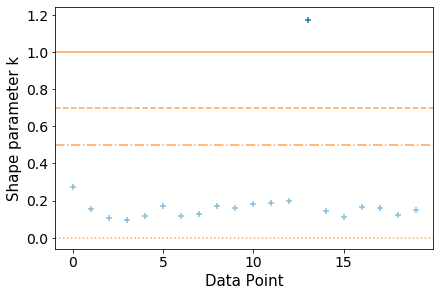

In [16]:
az.plot_khat(loo)

In [17]:
def pystan_refitter(stan_model, data_dict, sampling_kwargs=None, convert_kwargs=None):
    if sampling_kwargs is None:
        sampling_kwargs = {}
    if convert_kwargs is None:
        convert_kwargs = {}
    fit = stan_model.sampling(data=data_dict, **sampling_kwargs)
    idata = az.from_pystan(posterior=fit, **convert_kwargs)
    return idata

In [31]:
sampling_kwargs = {"iter": 1500, "chains": 6, "control": control}
convert_kwargs = {"posterior_predictive": 'y_hat', "observed_data": ['y'], "log_likelihood": 'log_lik'}
data_dict2 = {key: item-1 if not isinstance(item, np.ndarray) else np.concatenate((item[:13], item[14:])) for key, item in data_dict.items()}
idata2 = pystan_refitter(sm_lr, data_dict2, sampling_kwargs=sampling_kwargs, convert_kwargs=convert_kwargs)

In [32]:
az.loo(idata2, pointwise=True)

Computed from 4500 by 19 log-likelihood matrix

       Estimate       SE
IC_loo    96.79     5.83
p_loo      2.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       19  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

# Emcee wrapper

# PyMC wrapper